<a href="https://colab.research.google.com/github/WilliamJin123/betting/blob/main/research/quantevolve/ga_eth_arbitrage_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 GA-Evolved Parameters for an Ethereum Arbitrage Bot (Colab Demo)

This notebook demonstrates a **hybrid architecture** for arbitrage across AMMs:
- **Genetic Algorithm (offline)** evolves strategy parameters (thresholds, gas model, slippage guard, latency window).
- **Real-time heuristic executor (online)** uses the best parameters to act on opportunities in a **simulated AMM market**.
- **Baseline vs GA-optimized** comparison.

> ⚠️ This is a **simulation** for research/education. It does **not** execute real trades, connect to live networks, or provide financial advice.


In [ ]:
#@title Setup
import math, random, statistics, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

print('Env ready.')


Env ready.


## AMM Market Simulator

We approximate two constant-product AMMs (e.g., Uniswap v2 style) for pairs `ETH/USDC` on two venues (A and B).
- Each step simulates order flow and inventory drift, causing **price divergence**.
- We add **gas cost, latency, slippage**, and **MEV loss chance** as realism terms.


In [ ]:
#@title AMM + Market Simulator
from dataclasses import dataclass

@dataclass
class AMM:
    # Simple constant-product AMM (x*y=k) wrapper for price simulation.
    base_reserve: float   # e.g., ETH
    quote_reserve: float  # e.g., USDC
    fee_bps: int = 30     # 0.30% typical v2 pool fee (in bps)

    def price(self):
        # spot price: quote per base
        return self.quote_reserve / self.base_reserve

    def swap_base_for_quote(self, base_in: float):
        fee_multiplier = 1 - self.fee_bps / 10_000
        x, y = self.base_reserve, self.quote_reserve
        dx = base_in * fee_multiplier
        k = x * y
        new_x = x + dx
        new_y = k / new_x
        quote_out = y - new_y
        self.base_reserve = new_x
        self.quote_reserve = new_y
        return quote_out

    def swap_quote_for_base(self, quote_in: float):
        fee_multiplier = 1 - self.fee_bps / 10_000
        x, y = self.base_reserve, self.quote_reserve
        dy = quote_in * fee_multiplier
        k = x * y
        new_y = y + dy
        new_x = k / new_y
        base_out = x - new_x
        self.base_reserve = new_x
        self.quote_reserve = new_y
        return base_out


@dataclass
class MarketConfig:
    gas_usd_base: float = 1.50
    gas_usd_per_100k_gwei: float = 0.50
    mev_loss_prob: float = 0.03
    mev_loss_bps: float = 8
    latency_ms: int = 250
    slip_guard_bps: int = 50
    trade_size_usd: float = 5_000
    fee_bps_vault: int = 0


def simulate_step(ammA: AMM, ammB: AMM, cfg: MarketConfig):
    # simulate exogenous order flow causing reserves to move slightly
    def random_flow(amm: AMM):
        if random.random() < 0.5:
            size = abs(np.random.normal(0, 1000))
            amm.swap_quote_for_base(size)
        else:
            size = abs(np.random.normal(0, 0.3))
            amm.swap_base_for_quote(size)

    random_flow(ammA)
    random_flow(ammB)

    network_load = abs(np.random.normal(100, 60))
    gas_cost = cfg.gas_usd_base + cfg.gas_usd_per_100k_gwei * (network_load / 100.0)

    pA = ammA.price()
    pB = ammB.price()
    return pA, pB, gas_cost, network_load


def execute_arbitrage(amm_buy: AMM, amm_sell: AMM, cfg: MarketConfig, params):
    """Attempt a two-leg arb: buy base on cheaper venue, sell on expensive venue.

    params: dict with evolved strategy
      - threshold_bps: min gross edge required to act
      - gas_k: multiplier on gas model (risk-adjust)
      - slip_guard_bps: override slippage guard
      - latency_ms: override act latency
    """
    latency_ms = max(0, int(params.get('latency_ms', 250)))
    slip_guard_bps = max(0, int(params.get('slip_guard_bps', cfg.slip_guard_bps)))
    threshold_bps = max(0.0, float(params.get('threshold_bps', 10.0)))
    gas_k = max(0.1, float(params.get('gas_k', 1.0)))

    trade_usd = cfg.trade_size_usd

    import copy
    buy_copy = copy.deepcopy(amm_buy)
    sell_copy = copy.deepcopy(amm_sell)

    base_out = buy_copy.swap_quote_for_base(trade_usd)
    if base_out <= 0:
        return 0.0, False

    quote_back = sell_copy.swap_base_for_quote(base_out)

    gross_edge_bps = (quote_back - trade_usd) / trade_usd * 10_000

    spot_buy = amm_buy.price()
    spot_sell = amm_sell.price()
    exec_buy = trade_usd / base_out if base_out > 0 else float('inf')
    exec_sell = quote_back / base_out if base_out > 0 else 0.0
    buy_slip_bps = max(0.0, (exec_buy / spot_buy - 1.0) * 10_000)
    sell_slip_bps = max(0.0, (1.0 - exec_sell / spot_sell) * 10_000)
    if buy_slip_bps > slip_guard_bps or sell_slip_bps > slip_guard_bps:
        return 0.0, False

    latency_discount_bps = 0.01 * latency_ms
    effective_edge_bps = gross_edge_bps - latency_discount_bps

    if effective_edge_bps < threshold_bps:
        return 0.0, False

    if random.random() < cfg.mev_loss_prob:
        effective_edge_bps -= cfg.mev_loss_bps

    gas_usd = gas_k * 2.0 * (1.50 + 0.50)

    pnl = (effective_edge_bps / 10_000) * trade_usd - gas_usd
    if pnl <= 0:
        return 0.0, False

    base_out_real = amm_buy.swap_quote_for_base(trade_usd)
    quote_back_real = amm_sell.swap_base_for_quote(base_out_real)

    realized_edge_bps = (quote_back_real - trade_usd) / trade_usd * 10_000
    realized_pnl = (realized_edge_bps / 10_000) * trade_usd - gas_usd
    return realized_pnl, True


## Baseline vs GA-Evolved Strategy

- **Baseline Heuristic:** fixed threshold, guardrails, and latency assumption.
- **Genetic Algorithm (offline):** evolves parameters to maximize **mean PnL** over training episodes with penalties for variance and excessive trades.


In [ ]:
#@title Baseline Strategy + GA Framework
from dataclasses import dataclass
import numpy as np
import random

@dataclass
class StrategyParams:
    threshold_bps: float = 12.0
    gas_k: float = 1.0
    slip_guard_bps: int = 60
    latency_ms: int = 250

def run_episode(T=300, seed=None, params=None):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    ammA = AMM(base_reserve=1_000, quote_reserve=3_000_000, fee_bps=30)
    ammB = AMM(base_reserve=900, quote_reserve=2_700_000, fee_bps=30)
    cfg = MarketConfig()
    pnl_series = []
    trades = 0
    for t in range(T):
        pA, pB, gas_cost, network_load = simulate_step(ammA, ammB, cfg)
        if pA < pB:
            pnl, did = execute_arbitrage(ammA, ammB, cfg, params or {})
        else:
            pnl, did = execute_arbitrage(ammB, ammA, cfg, params or {})
        if did:
            trades += 1
        pnl_series.append(pnl)
    return {
        'pnl_total': float(np.sum(pnl_series)),
        'pnl_mean': float(np.mean(pnl_series)),
        'pnl_std': float(np.std(pnl_series)),
        'trades': trades,
        'series': pnl_series
    }

def fitness(stats):
    return stats['pnl_total'] - 0.5*stats['pnl_std'] - 0.1*max(0, stats['trades']-20)

def baseline_run(reps=5):
    base = StrategyParams()
    res = []
    for i in range(reps):
        stats = run_episode(T=300, seed=100+i, params=base.__dict__)
        res.append(stats)
    agg = {
        'pnl_total_mean': float(np.mean([r['pnl_total'] for r in res])),
        'pnl_std_mean': float(np.mean([r['pnl_std'] for r in res])),
        'trades_mean': float(np.mean([r['trades'] for r in res])),
    }
    return base.__dict__, agg, res

def random_individual():
    return {
        'threshold_bps': float(np.clip(np.random.normal(12, 8), 0, 80)),
        'gas_k': float(np.clip(np.random.normal(1.0, 0.5), 0.1, 3.0)),
        'slip_guard_bps': int(np.clip(np.random.normal(60, 40), 10, 200)),
        'latency_ms': int(np.clip(np.random.normal(250, 150), 10, 1200)),
    }

def mutate(ind, sigma=0.2):
    child = dict(ind)
    child['threshold_bps'] = float(np.clip(ind['threshold_bps'] + np.random.normal(0, 8*sigma), 0, 120))
    child['gas_k'] = float(np.clip(ind['gas_k'] * np.exp(np.random.normal(0, 0.3*sigma)), 0.1, 3.0))
    child['slip_guard_bps'] = int(np.clip(ind['slip_guard_bps'] + np.random.normal(0, 40*sigma), 5, 400))
    child['latency_ms'] = int(np.clip(ind['latency_ms'] + np.random.normal(0, 150*sigma), 5, 2000))
    return child

def crossover(a, b):
    c = {}
    for k in a.keys():
        c[k] = a[k] if random.random() < 0.5 else b[k]
    return c

def evaluate_individual(ind, reps=3, seed0=2000):
    stats_list = [ run_episode(T=300, seed=seed0+i, params=ind) for i in range(reps) ]
    fit_vals = [ fitness(s) for s in stats_list ]
    return {
        'fitness': float(np.mean(fit_vals)),
        'pnl_total_mean': float(np.mean([s['pnl_total'] for s in stats_list])),
        'pnl_std_mean': float(np.mean([s['pnl_std'] for s in stats_list])),
        'trades_mean': float(np.mean([s['trades'] for s in stats_list])),
        'ind': ind
    }

def evolve(pop_size=20, gens=12, elite_k=4, reps=3):
    pop = [random_individual() for _ in range(pop_size)]
    history = []
    for g in range(gens):
        scored = [evaluate_individual(ind, reps=reps, seed0=3000+7*g) for ind in pop]
        scored.sort(key=lambda x: x['fitness'], reverse=True)
        history.append(scored[0])
        elites = [s['ind'] for s in scored[:elite_k]]
        next_pop = elites[:]
        while len(next_pop) < pop_size:
            p1, p2 = random.sample(elites, k=2)
            child = crossover(p1, p2)
            if random.random() < 0.9:
                child = mutate(child, sigma=0.8)
            next_pop.append(child)
        pop = next_pop
        best = scored[0]
        print(f"Gen {g+1}/{gens}: fitness={best['fitness']:.2f} pnl={best['pnl_total_mean']:.2f} trades={best['trades_mean']:.1f} ind={best['ind']}")
    final_best = history[-1]
    return final_best, history


## Train GA and Compare Against Baseline

In [ ]:
#@title Train GA (offline) and compare
baseline_params, baseline_agg, baseline_runs = baseline_run(reps=6)
print('Baseline params:', baseline_params)
print('Baseline agg:', baseline_agg)

best, hist = evolve(pop_size=24, gens=10, elite_k=6, reps=3)
ga_params = best['ind']
print('\nBest GA params:', ga_params)

def eval_many(params, seeds):
    out = []
    for s in seeds:
        out.append(run_episode(T=300, seed=s, params=params))
    pnl_total = [o['pnl_total'] for o in out]
    trades = [o['trades'] for o in out]
    return {
        'pnl_total_mean': float(np.mean(pnl_total)),
        'pnl_total_std': float(np.std(pnl_total)),
        'trades_mean': float(np.mean(trades)),
        'raw': out
    }

heldout = [700+i for i in range(8)]
eval_base = eval_many(baseline_params, heldout)
eval_ga = eval_many(ga_params, heldout)

print('\nHeld-out evaluation:')
print('Baseline:', eval_base)
print('GA     :', eval_ga)


Baseline params: {'threshold_bps': 12.0, 'gas_k': 1.0, 'slip_guard_bps': 60, 'latency_ms': 250}
Baseline agg: {'pnl_total_mean': 16.869677594164386, 'pnl_std_mean': 0.601091316927933, 'trades_mean': 2.6666666666666665}
Gen 1/10: fitness=32.01 pnl=32.55 trades=3.0 ind={'threshold_bps': 15.86920263889644, 'gas_k': 0.2860347695862613, 'slip_guard_bps': 60, 'latency_ms': 367}
Gen 2/10: fitness=30.85 pnl=31.33 trades=2.0 ind={'threshold_bps': 31.828182137282006, 'gas_k': 0.9200803081377578, 'slip_guard_bps': 125, 'latency_ms': 284}
Gen 3/10: fitness=28.44 pnl=28.95 trades=2.7 ind={'threshold_bps': 19.147629217793774, 'gas_k': 0.47510797369375996, 'slip_guard_bps': 56, 'latency_ms': 329}
Gen 4/10: fitness=58.05 pnl=59.03 trades=3.0 ind={'threshold_bps': 30.10101563961058, 'gas_k': 0.2625122784282564, 'slip_guard_bps': 108, 'latency_ms': 384}
Gen 5/10: fitness=46.72 pnl=47.66 trades=2.0 ind={'threshold_bps': 45.46711738510728, 'gas_k': 0.272087480953536, 'slip_guard_bps': 94, 'latency_ms': 21

## Results Visualization

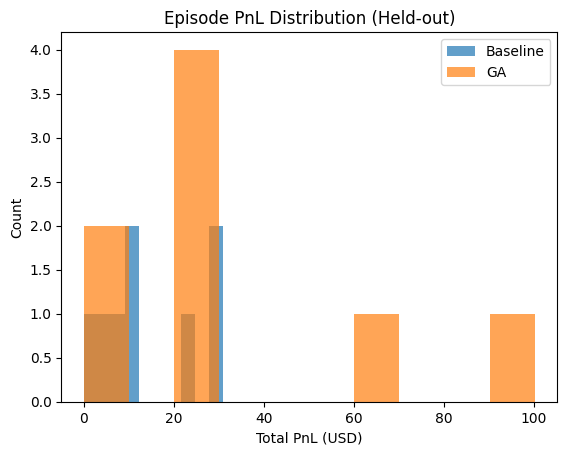

In [ ]:
#@title Plot distribution of episode PnL (held-out)
base_pnls = [r['pnl_total'] for r in eval_base['raw']]
ga_pnls = [r['pnl_total'] for r in eval_ga['raw']]

plt.figure()
plt.hist(base_pnls, bins=10, alpha=0.7, label='Baseline')
plt.hist(ga_pnls, bins=10, alpha=0.7, label='GA')
plt.legend()
plt.title('Episode PnL Distribution (Held-out)')
plt.xlabel('Total PnL (USD)')
plt.ylabel('Count')
plt.show()


/tmp/ipython-input-1237776596.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([base_trades, ga_trades], labels=['Baseline', 'GA'])


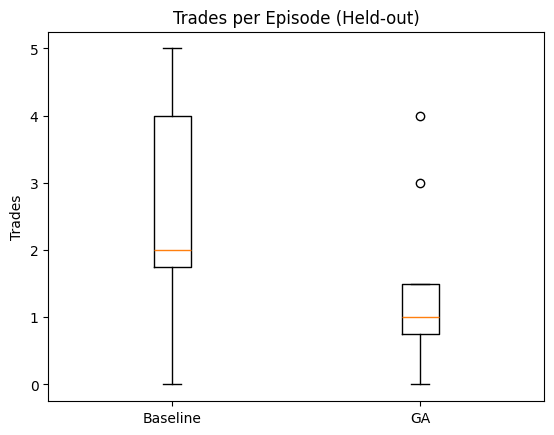

In [ ]:
#@title Trades per Episode (held-out)
base_trades = [r['trades'] for r in eval_base['raw']]
ga_trades = [r['trades'] for r in eval_ga['raw']]

plt.figure()
plt.boxplot([base_trades, ga_trades], labels=['Baseline', 'GA'])
plt.title('Trades per Episode (Held-out)')
plt.ylabel('Trades')
plt.show()


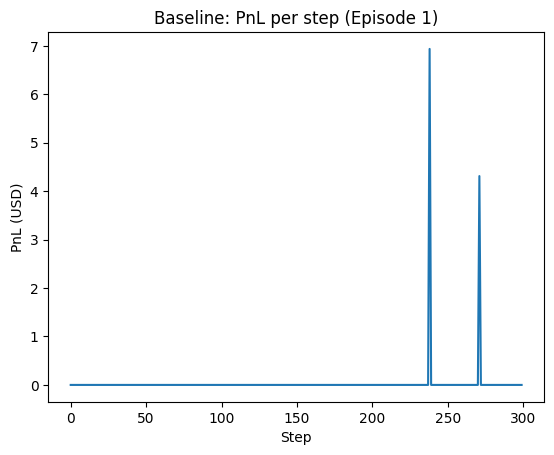

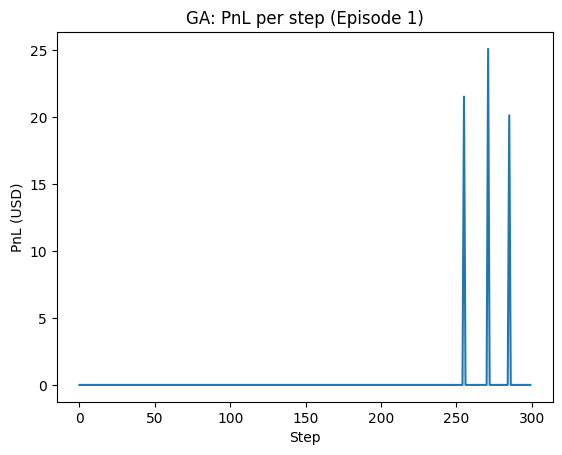

In [ ]:
#@title Example PnL time series (one episode each)
plt.figure()
plt.plot(eval_base['raw'][0]['series'])
plt.title('Baseline: PnL per step (Episode 1)')
plt.xlabel('Step')
plt.ylabel('PnL (USD)')
plt.show()

plt.figure()
plt.plot(eval_ga['raw'][0]['series'])
plt.title('GA: PnL per step (Episode 1)')
plt.xlabel('Step')
plt.ylabel('PnL (USD)')
plt.show()


## Next Steps & Extensions

- Swap simulator for **Uniswap v3 concentrated liquidity** logic.
- Add **multi-hop** paths and **cross-exchange fees**.
- Model **private order flow** by sending transactions to a simulated **private mempool** to reduce MEV risk.
- Replace heuristic executor with a **tabular RL** or **policy-gradient** agent that uses the GA-evolved parameters as priors.
- Integrate a **robust risk budget**: cap daily loss, circuit breaker on volatility spikes, dynamic sizing.
